# Using Selection Function Code

## SNC 100 pc Sample

Below are some examples on how to use the SNC Selection Function code. First, we will use the code on the stars with a spectrum in `mwm_snc_100pc` cartons. By default, this will load the precomputed selection function. All that is needed is to input a csv file with Gaia data with the following columns: source_id, ra, ra_error, dec, dec_error, parallax, parallax_error, g_rp,  phot_g_mean_mag, phot_g_mean_flux_over_error.

Once the data is loaded, the code will construct the selection function by binning the data into the appropriate bins. It will also use `gaiaunlimited` to calculate $\mathcal{S}_\mathcal{C}^\mathsf{parent}(q)$ based on sky loacation Gaia G magnitude. Then, you just need to sample the posteriors of $V_\mathrm{max}$ and $\mathcal{S}_\mathcal{C}(q|q \ \mathsf{in \ parent})$.

In [1]:
from snc_sf.selection_function import SNCSelectionFunction
import matplotlib.pylab as plt
import os
import numpy as np
import polars as pl
%matplotlib inline
plt.style.use('%s/mystyle.mplstyle' % os.environ['MPL_STYLES'])


sncsf = SNCSelectionFunction('../../obs_100pc_dr19.csv')
sncsf.sample_posterior(1000)

/Users/imedan/Desktop/VU_PostDoc_Research/SDSS_V/selection_function/snc_sf/src/snc_sf/utils.py:140: RuntimeWarning: invalid value encountered in log10
  MG = phot_g_mean_mag + 5 * np.log10(1e-3 * parallax) + 5


### Luminsoity Function

Once the posterior samples are drawn, it is easy to bootstrap statstical distirubtions using `snc_sf.selection_function.SNCSelectionFunction.bootstrap_values`. The below example is for the Gaia luminosity function for the 100 pc stars. To do this you need to provide a few things to this function. 

First, is a function that describes what you are trying to calculate. The first input should always be the weights, defined as $[\mathcal{S}_\mathcal{C}(q|q \ \mathsf{in \ parent}) \times \mathcal{S}_\mathcal{C}^\mathsf{parent}(q) \times V_\mathrm{max}]^{-1}$. Following this are a set of data arguments and additional arguments, which are described below.

Second, you must provide some filter on the data. In the below example we remove white dwarfs from the sample using a cut on the HR diagram. As the code relies on [polars](https://pola.rs) to store the darta, polars expressions must be used.

The next set of arguments should be any additional data, that can be calculated from the columns in the data file (i.e. source_id, ra, ra_error, dec, dec_error, parallax, parallax_error, g_rp,  phot_g_mean_mag, phot_g_mean_flux_over_error). Again, polars expressions must be used.

Finally, any additional arguments to the function must be listed as inputs. Here, we include the bins we want to calculate the luminosity function with.

In [2]:
def lum_func(weights, G, plx, plx_err, MG_lum):
    MG = G + 5 * np.log10(1e-3 * np.random.normal(plx, plx_err)) + 5
    N, _ = np.histogram(MG, weights=weights, bins=MG_lum)
    N /=  (MG_lum[1] - MG_lum[0])
    return N


# create filter expresion
# This removes faint sources and white dwarfs from the sample
MG = sncsf.data['phot_g_mean_mag'] + 5 * np.log10(1e-3 * sncsf.data['parallax']) + 5
filt = (pl.col("phot_g_mean_mag") < 20)  & (MG < 10 * sncsf.data['g_rp'] + 5)

# data to be passed to lum_func
# This is an Polars expression that is MG in lum_func()
data_expr = [(pl.col('phot_g_mean_mag')),
             (pl.col('parallax')),
             (pl.col('parallax_error'))]

# bins for the lum_func
# This will be passed as the final argument in lum_func()
MG_lum = np.linspace(0, 18, 75)
args = [MG_lum]

N_boot = sncsf.bootstrap_values(lum_func, filt, data_expr, args)


/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_43285/512857410.py:2: RuntimeWarning: invalid value encountered in log10
  MG = G + 5 * np.log10(1e-3 * np.random.normal(plx, plx_err)) + 5


let us also calculate the luminosity function without accounting for the selection function.

In [3]:
MG_data = sncsf.data.select(MG).filter(filt).to_numpy().reshape((-1, ))

N, _ = np.histogram(MG_data, weights=np.zeros(len(MG_data)) + 1 / (4/3 * np.pi * 100 ** 3), bins=MG_lum)
N /=  (MG_lum[1] - MG_lum[0])


For reference we will also plot the Gaia luminoisty function from the [Gaia Catalog of Narby Stars](https://www.aanda.org/articles/aa/full_html/2021/05/aa39498-20/aa39498-20.html).

In [4]:
GNSC = np.genfromtxt('../../GNSS_lum_func-fig16.csv', delimiter=',', skip_header=1)

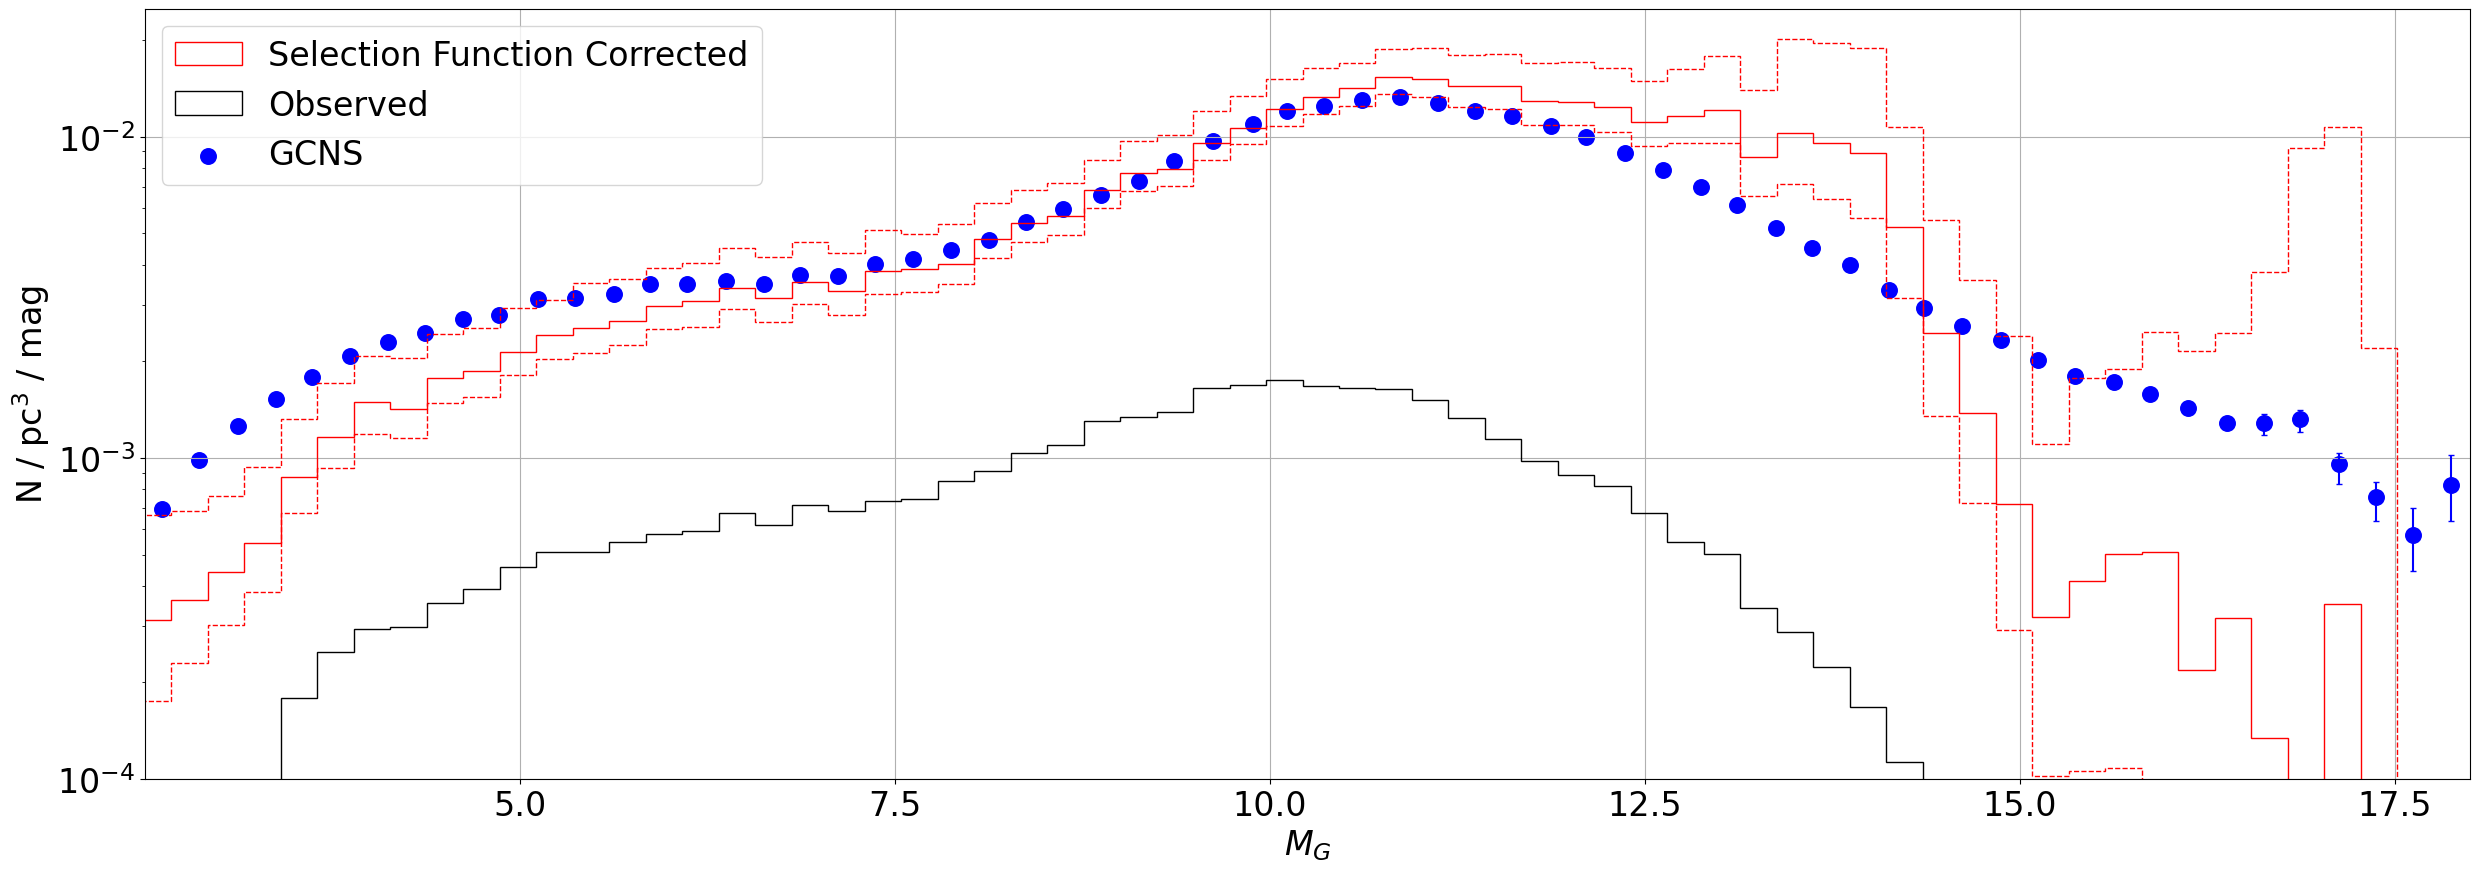

In [5]:
plt.figure(figsize=(30, 10))

plt.hist(MG_lum[:-1], bins=MG_lum, weights=np.nanmedian(N_boot, axis=0), label='Selection Function Corrected',
        histtype='step', lw=5, edgecolor='r')
plt.hist(MG_lum[:-1], bins=MG_lum,
         weights=np.nanpercentile(N_boot, 2.5, axis=0),
         label=None,
        histtype='step', lw=1, linestyle='--', edgecolor='r')
plt.hist(MG_lum[:-1], bins=MG_lum,
         weights=np.nanpercentile(N_boot, 97.5, axis=0),
         label=None,
        histtype='step', lw=1, linestyle='--', edgecolor='r')

plt.hist(MG_lum[:-1], bins=MG_lum, weights=N, label='Observed',
        histtype='step', lw=5, edgecolor='k')

plt.scatter(GNSC[:, 0], GNSC[:, 1], c='b', label='GCNS', s=125)
plt.errorbar(GNSC[:, 0], GNSC[:, 1], yerr=[GNSC[:, 2] - GNSC[:, 1], GNSC[:, 1] - GNSC[:, 3]],
             fmt='none', ecolor='b')

plt.xticks(np.arange(5, 22.5, 2.5))

plt.grid()
plt.xlim((2.5, 18))
plt.ylim((1e-4, 2.5e-2))
plt.yscale('log')
plt.xlabel(r'$M_G$')
plt.ylabel(r'N / pc$^3$ / mag')
plt.legend()
plt.savefig('paper_plots/luminosity_func.png', bbox_inches='tight')
plt.show()




### Number Density

Similar to the above, we can calculate the number density of stars of different spectral types. We will comapre these values to results from the literature. This is a simpler exampled, where we do not need the data arguments and additional arguments for the calculation.

In [6]:
truth = {}
truth['RECONS'] = [['k', '^'],
                   [2-0.03, 0.0105, 0.0016],
                   [3-0.03, 0.0676, 0.0040]]

truth['EMM'] = [['b', '*'],
                [0-0.02, 0.0024, 0.0003]]

truth['Mamajek+08'] = [['y', 's'],
                       [1-0.01, 0.0033, 0.0004]]

truth['Kirkpatrick+12'] = [['m', 'D'],
                           [1+0.01, 0.0037, 0.0013],
                           [2+0.01, 0.0135, 0.0025],
                           [3+0.01, 0.0859, 0.0086]]

truth['Winters+19'] = [['c', 'P'],
                       [3+0.02, 0.0917, 0.0132]]






In [7]:
def num_density(weights):
    return np.nansum(weights)

MG_cuts = [[2.51, 4.325],
           [4.325, 5.553],
           [5.553, 8.10 ],
           [8.10, 16.60]]


labels = ['F Dwarfs', 'G Dwarfs', 'K Dwarfs', 'M Dwarfs']

num_dens_all = np.zeros((len(MG_cuts), 3))

MG = sncsf.data['phot_g_mean_mag'] + 5 * np.log10(1e-3 * sncsf.data['parallax']) + 5

for it in range(len(MG_cuts)):
    filt = (pl.col("phot_g_mean_mag") < 20) &\
           (MG > MG_cuts[it][0]) & (MG < MG_cuts[it][1]) & (MG < 10 * sncsf.data['g_rp'] + 5)
    num_dens = sncsf.bootstrap_values(num_density, filt)
    num_dens_all[it] = np.nanpercentile(num_dens, [2.5, 50, 97.5])




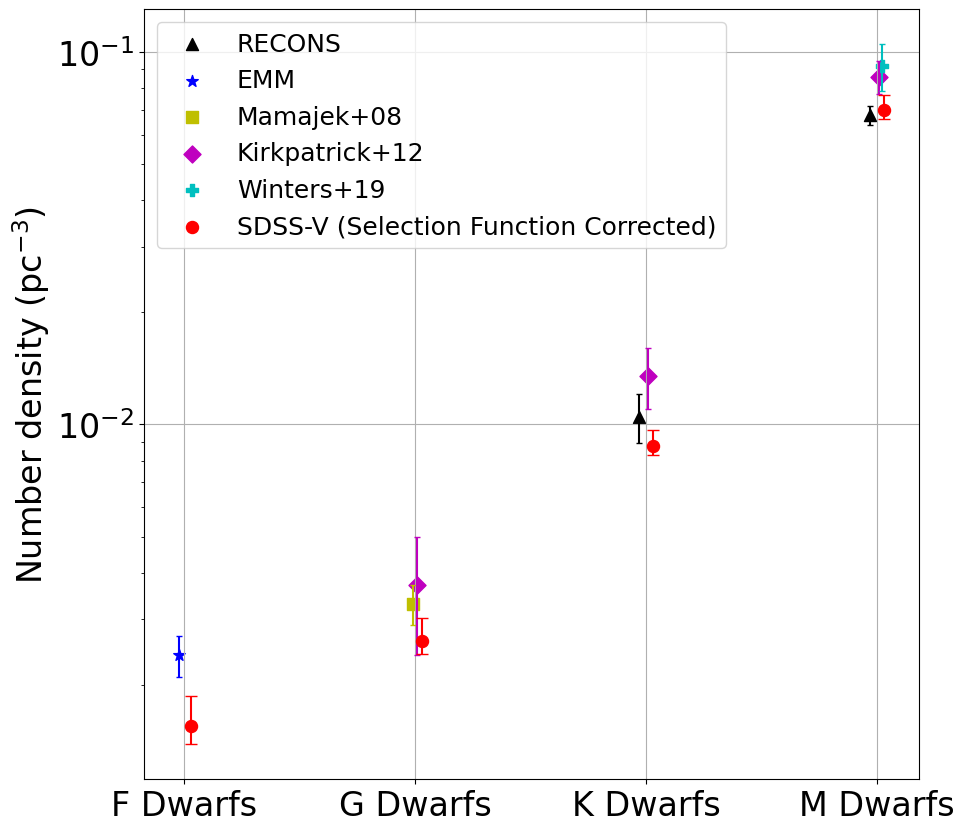

In [8]:
plt.figure(figsize=(10, 10))

for k in truth.keys():
    label = k
    c = truth[k][0][0]
    marker = truth[k][0][1]
    data = np.array(truth[k][1:])
    # rand = np.random.normal(0, 0.01, len(data[:, 0]))
    plt.scatter(data[:, 0], data[:, 1], c=c, label=label, marker=marker, s=75)
    plt.errorbar(data[:, 0], data[:, 1], yerr=data[:, 2],
                 fmt='none', ecolor=c)

plt.scatter(np.arange(len(MG_cuts))+0.03, num_dens_all[:, 1], c='r', label='SDSS-V (Selection Function Corrected)',
            zorder=9999, s=75)
plt.errorbar(np.arange(len(MG_cuts))+0.03, num_dens_all[:, 1], yerr=np.diff(num_dens_all).T,
             fmt='none', ecolor='r', capsize=4)

plt.grid()
plt.yscale('log')
plt.ylabel(r'Number density (pc$^{-3}$)')
plt.legend(ncol=1, prop={'size': 18})
# plt.ylim(1e-3, 1e0)
plt.xticks(np.arange(len(MG_cuts)), labels)
plt.savefig('paper_plots/number_density.png', bbox_inches='tight')
plt.show()




### HR Diagram

Finally, we can look the selection function corrected HR diagram. This will allow us to see the completeness of the sample across the HR diagram. This example is very similar to how we calculated the above luminosity function.

In [9]:
def HR_diagram(weights, G_RP, MG, G_RPbins, MG_bins):
    N, _, _ = np.histogram2d(G_RP, MG,
                             weights=weights, bins=[G_RPbins, MG_bins])
    mag2 = (G_RPbins[1] - G_RPbins[0]) * (MG_bins[1] - MG_bins[0])
    N /= mag2
    return N

filt = (pl.col("phot_g_mean_mag") < 20)

data_expr = [(pl.col('g_rp')),
             (pl.col('phot_g_mean_mag') + 5 * np.log10(1e-3 * pl.col('parallax')) + 5)]

Nbin = 100
G_RPbins = np.linspace(-0.5, 2.15, Nbin)
MG_bins = np.linspace(0, 18, Nbin)
args = [G_RPbins, MG_bins]

N_boot = sncsf.bootstrap_values(HR_diagram, filt, data_expr, args)


In [10]:
GRP_data = sncsf.data.filter(filt)['g_rp'].to_numpy().reshape((-1, ))
MG_data = sncsf.data.filter(filt).select(data_expr[1]).to_numpy().reshape((-1, ))

N = HR_diagram(np.zeros(len(MG_data)) + 1 / (4/3 * np.pi * 100 ** 3),
               GRP_data, MG_data, G_RPbins, MG_bins)

/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_43285/1246200219.py:23: RuntimeWarning: divide by zero encountered in divide
  dens = ax3.imshow(N.T / np.nanmedian(N_boot, axis=0).T, origin='lower',
/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_43285/1246200219.py:23: RuntimeWarning: invalid value encountered in divide
  dens = ax3.imshow(N.T / np.nanmedian(N_boot, axis=0).T, origin='lower',


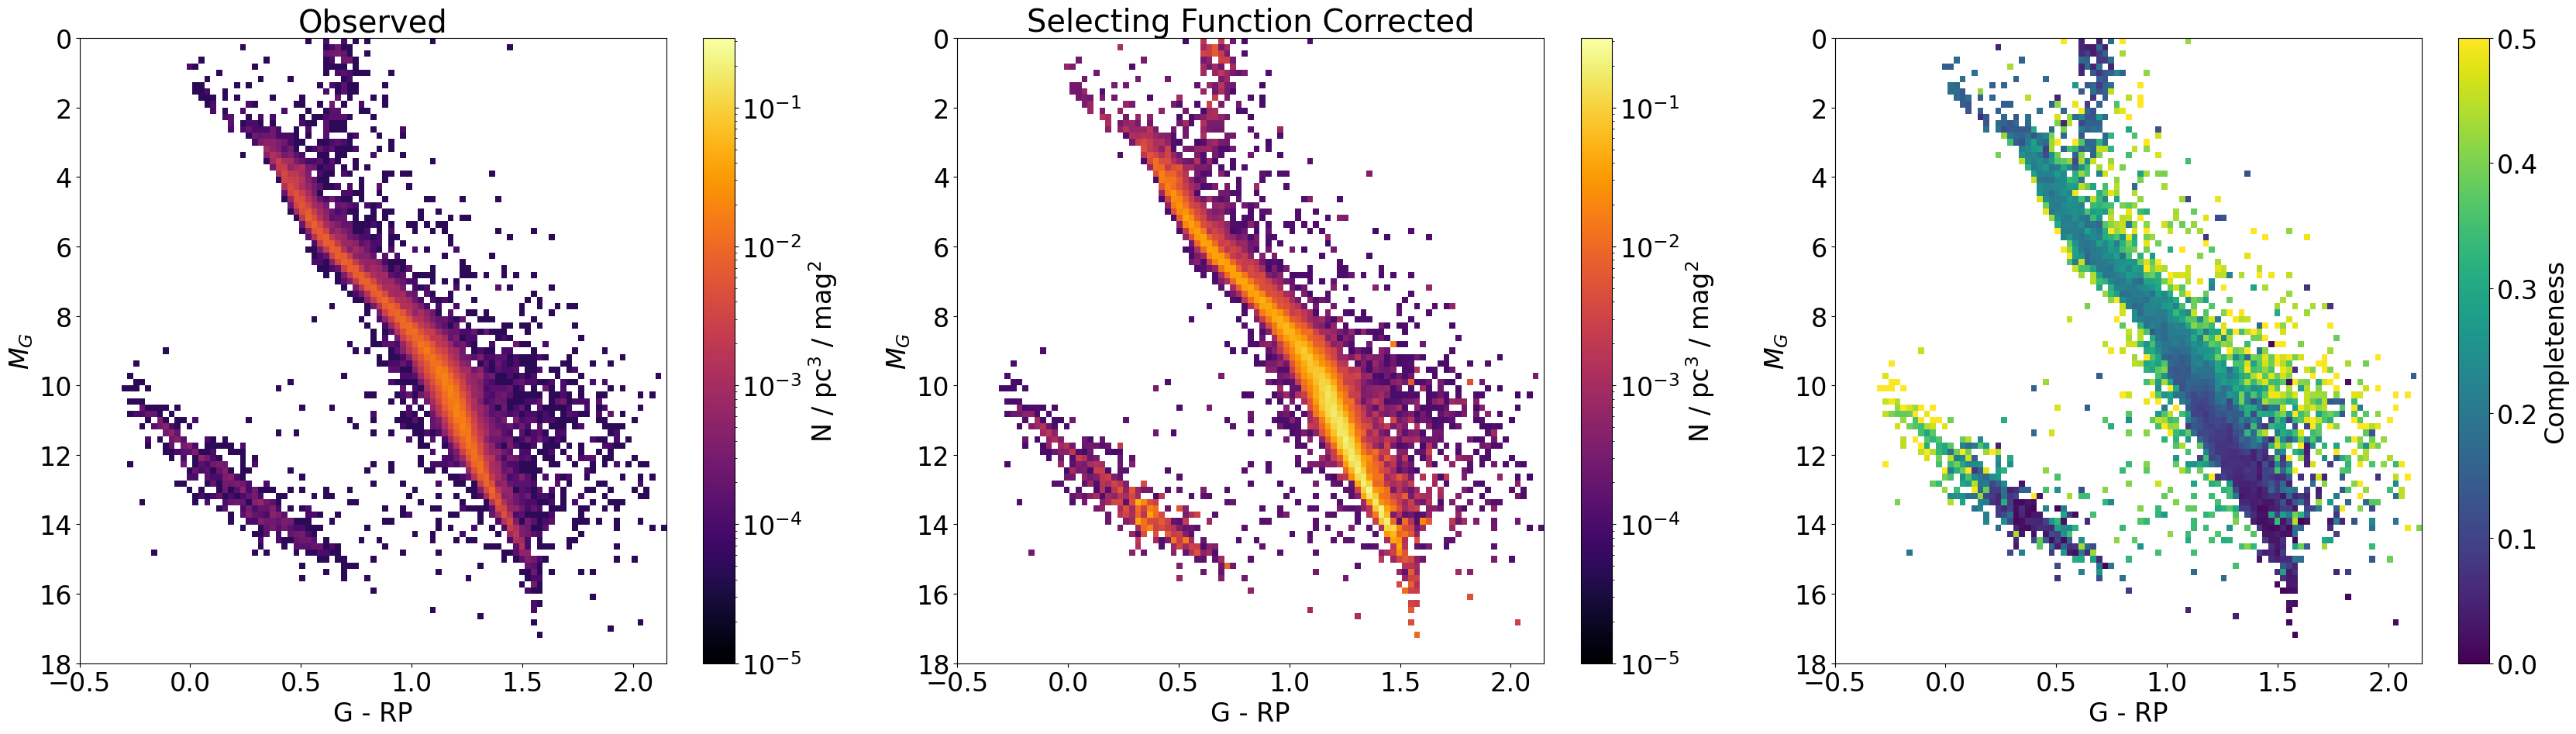

In [11]:
from matplotlib.colors import LogNorm

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(34, 10))

dens = ax1.imshow(N.T, origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='inferno', norm=LogNorm(1e-5, 10 ** -0.5))
ax1.invert_yaxis()
plt.colorbar(dens, ax=ax1, label=r'N / pc$^3$ / mag$^2$')
ax1.set_title('Observed')
ax1.set_xlabel('G - RP')
ax1.set_ylabel(r'$M_G$')

dens = ax2.imshow(np.nanmedian(N_boot, axis=0).T, origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='inferno', norm=LogNorm(1e-5, 10 ** -0.5))
ax2.invert_yaxis()
plt.colorbar(dens, ax=ax2, label=r'N / pc$^3$ / mag$^2$')
ax2.set_title('Selecting Function Corrected')
ax2.set_xlabel('G - RP')
ax2.set_ylabel(r'$M_G$')

dens = ax3.imshow(N.T / np.nanmedian(N_boot, axis=0).T, origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='viridis', vmin=0, vmax=0.5)
ax3.invert_yaxis()
plt.colorbar(dens, ax=ax3, label=r'Completeness')
ax3.set_xlabel('G - RP')
ax3.set_ylabel(r'$M_G$')
plt.tight_layout()
plt.savefig('paper_plots/HR_diagram.png', bbox_inches='tight')
plt.show()


## White Dwarfs within 100 pc

This code also works for any subsample within 100 pc. As an example, below we will calculate the selection function for the SDSS-V DR19 white dwarfs within 100 pc. We will then plot the selection function corrected HR diagram for these sources.

In [12]:
wdsf = SNCSelectionFunction('../../obs_100pc_wd_dr19.csv')
wdsf.sample_posterior(1000)


In [13]:
def HR_diagram(weights, G_RP, MG, G_RPbins, MG_bins):
    N, _, _ = np.histogram2d(G_RP, MG,
                             weights=weights, bins=[G_RPbins, MG_bins])
    mag2 = (G_RPbins[1] - G_RPbins[0]) * (MG_bins[1] - MG_bins[0])
    N /= mag2
    return N

filt = (pl.col("phot_g_mean_mag") < 20)

data_expr = [(pl.col('phot_bp_mean_mag') - pl.col('phot_rp_mean_mag')),
             (pl.col('phot_g_mean_mag') + 5 * np.log10(1e-3 * pl.col('parallax')) + 5)]

Nbin = 75
G_RPbins = np.linspace(-0.6, 1.7, Nbin)
MG_bins = np.linspace(5, 17, Nbin)
args = [G_RPbins, MG_bins]

N_boot = wdsf.bootstrap_values(HR_diagram, filt, data_expr, args)




In [14]:
GRP_data = wdsf.data.filter(filt).select(data_expr[0]).to_numpy().reshape((-1, ))
MG_data = wdsf.data.filter(filt).select(data_expr[1]).to_numpy().reshape((-1, ))

N = HR_diagram(np.zeros(len(MG_data)) + 1 / (4/3 * np.pi * 100 ** 3),
               GRP_data, MG_data, G_RPbins, MG_bins)


We will compare this result to Figure 10 from [Rix et al. 2021](https://iopscience.iop.org/article/10.3847/1538-3881/ac0c13).
 Qualitatively, the Selection Function corrected HR diagram of the white
 dwarfs looks quite similar to the results from this work.

/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_43285/2807906815.py:5: RuntimeWarning: divide by zero encountered in log10
  dens = ax1.imshow(np.log10(N.T), origin='lower',
/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_43285/2807906815.py:14: RuntimeWarning: divide by zero encountered in log10
  dens = ax2.imshow(np.log10(np.nanmedian(N_boot, axis=0).T), origin='lower',


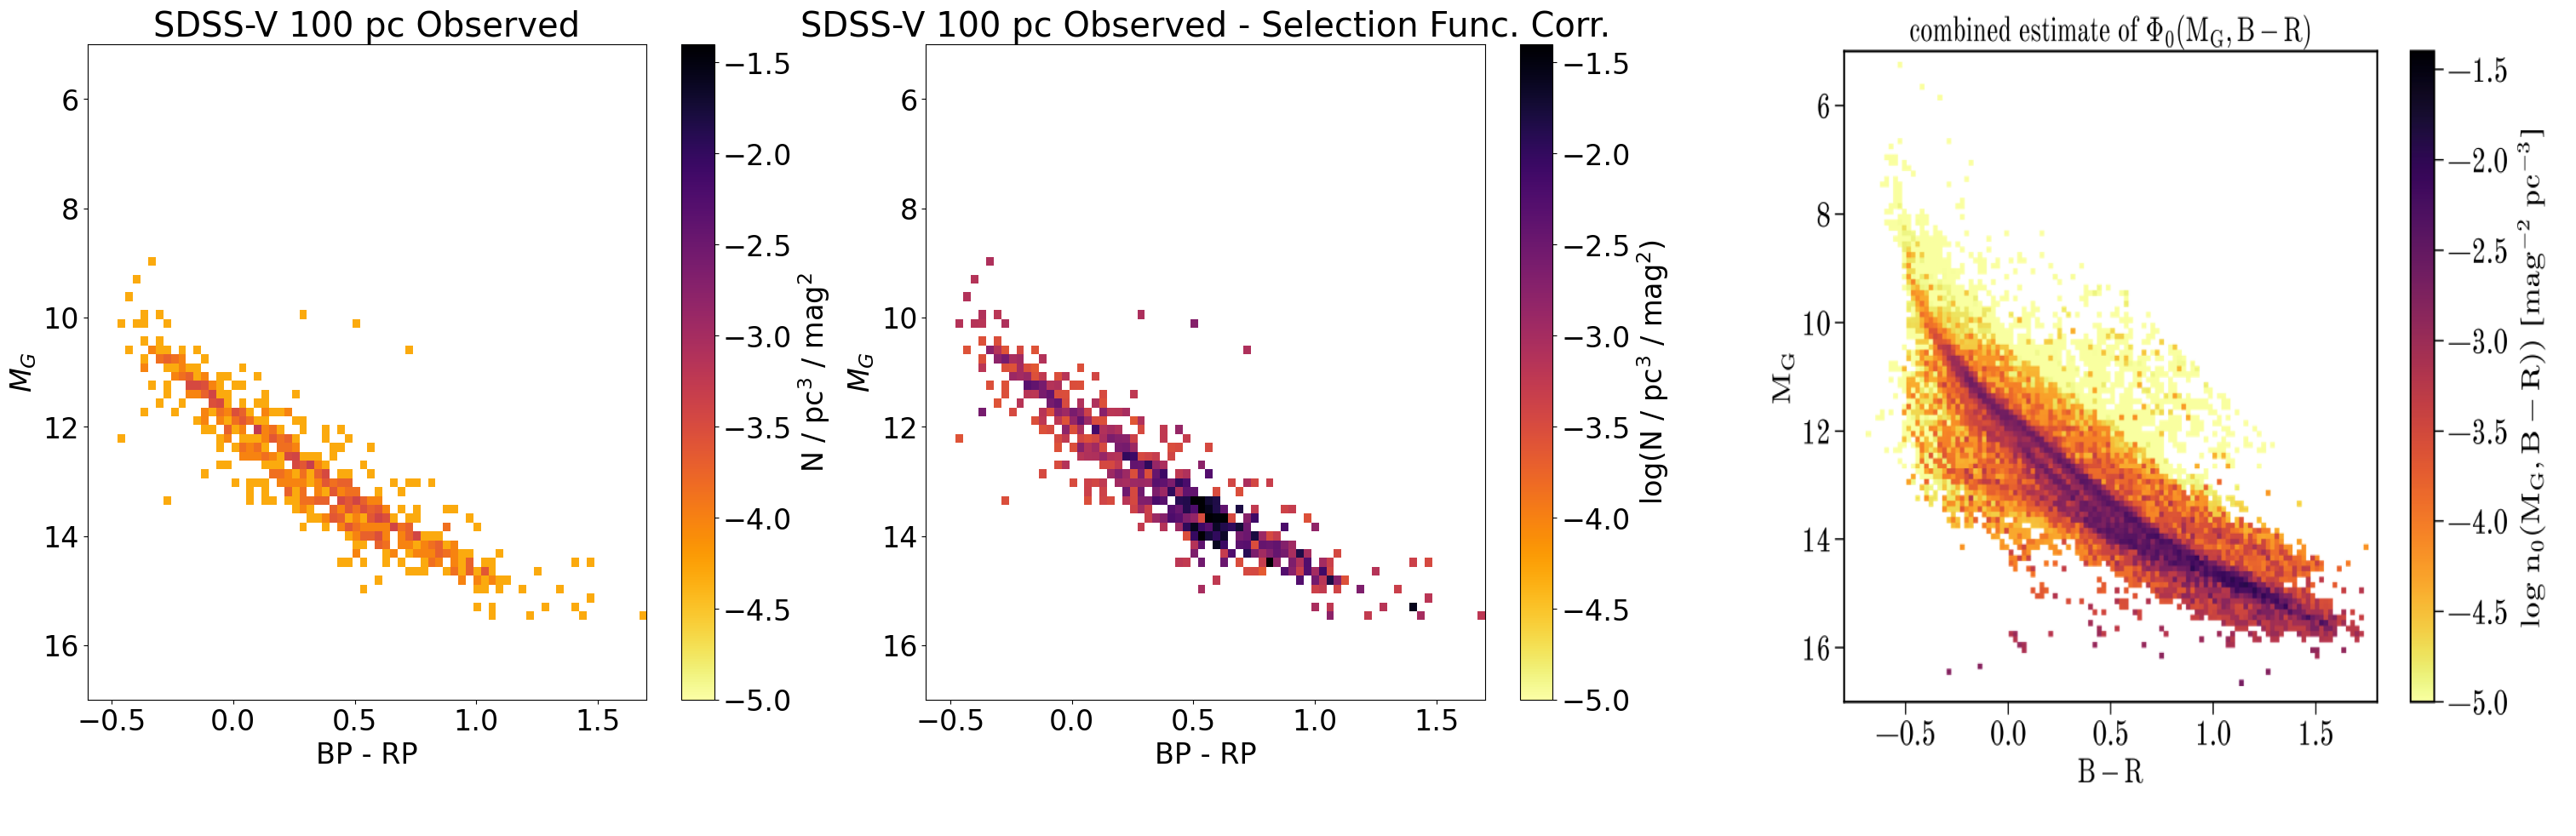

In [15]:
import matplotlib.image as mpimg

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(36, 10))

dens = ax1.imshow(np.log10(N.T), origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='inferno_r', vmin=-5, vmax=-1.4)
ax1.invert_yaxis()
plt.colorbar(dens, ax=ax1, label=r'N / pc$^3$ / mag$^2$')
ax1.set_title('SDSS-V 100 pc Observed')
ax1.set_xlabel('BP - RP')
ax1.set_ylabel(r'$M_G$')

dens = ax2.imshow(np.log10(np.nanmedian(N_boot, axis=0).T), origin='lower',
                  extent=(G_RPbins.min(), G_RPbins.max(), MG_bins.min(), MG_bins.max()),
                   aspect='auto', cmap='inferno_r', vmin=-5, vmax=-1.4)
ax2.invert_yaxis()
plt.colorbar(dens, ax=ax2, label=r'log(N / pc$^3$ / mag$^2$)')
ax2.set_title('SDSS-V 100 pc Observed - Selection Func. Corr.')
ax2.set_xlabel('BP - RP')
ax2.set_ylabel(r'$M_G$')

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0-0.15, pos.width*1.15, pos.height*1.25])
image = mpimg.imread('HW_WD_sf.png')
ax3.imshow(image, aspect='auto')
ax3.axis('off')


plt.show()
